
## 1.Import the required packages and libraries📚
You don't have them ? run this:
```bash
pip install -r requirements.txt
```

In [1691]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## 2.Setup & Data Loading📈
-------------------------------------------------------------------------------------------------------------------------------------
###### loading dataset from a .csv file and convert the numerical attributes that are in string form to the numerical form

In [1692]:
df = pd.read_csv("../data/House_price.csv")
df['Area_num'] = df['Area'].str.replace(',', '').str.strip().astype(int)
df.drop("Area", axis=1, inplace=True)
df['Area'] = df['Area_num']
df.drop("Area_num", axis=1, inplace=True)

## 3.Apply filters to remove the wrong tuples❌

-------------------------------------------------------------------------------------------------------------------------------------

###### the conditions for a correct tuple :
<ul>
<li> 0 < Area < 350 </li>
<li> Area / number of bedrooms >38</li>
<li> the Address shouldn't be null</li>
</ul>

In [1693]:
df = df[(df['Area'] > 0) & (df['Area'] <= 350) &(df['Room']<6) & ((df['Area']/df['Room'])> 38) &(df['Address'].notna())]

## 4.Data review

#### 4.1 Which neighborhoods exist in our data?🏡 :

-------------------------------------------------------------------------------------------------------------------------------------

Shahran , Pardis , Shahrake Qods , Shahrake Gharb , North Program Organization , Andisheh , West Ferdows Boulevard , Narmak , Saadat Abad , Zafar , Islamshahr , Pirouzi , Shahrake Shahid Bagheri , Moniriyeh , Velenjak , Amirieh , Southern Janatabad , Salsabil , Zargandeh , Feiz Garden , Water Organization , nan , ShahrAra , Gisha , Ray , Abbasabad , Ostad Moein , Farmanieh , Parand , Punak , Qasr-od-Dasht , Aqdasieh , Pakdasht , Railway , Central Janatabad , East Ferdows Boulevard , Pakdasht KhatunAbad , Sattarkhan , Baghestan , Shahryar , Northern Janatabad , Daryan No , Southern Program Organization , Rudhen , West Pars , Afsarieh , Marzdaran , Dorous , Sadeghieh , Chahardangeh , Baqershahr , Jeyhoon , Lavizan , Shams Abad , Fatemi , Keshavarz Boulevard , Kahrizak , Qarchak , Northren Jamalzadeh , Azarbaijan , Bahar , Persian Gulf Martyrs Lake , Beryanak , Heshmatieh , Elm-o-Sanat , Golestan , Shahr-e-Ziba , Pasdaran , Chardivari , Gheitarieh , Kamranieh , Gholhak , Heravi , Hashemi , Dehkade Olampic , Damavand , Republic , Zaferanieh , Qazvin Imamzadeh Hassan , Niavaran , Valiasr , Qalandari , Amir Bahador , Ekhtiarieh , Ekbatan , Absard , Haft Tir , Mahallati , Ozgol , Tajrish , Abazar , Koohsar , Hekmat , Parastar , Lavasan , Majidieh , Southern Chitgar , Karimkhan , Si Metri Ji , Karoon , Northern Chitgar , East Pars , Kook , Air force , Sohanak , Komeil , Azadshahr , Zibadasht , Amirabad , Dezashib , Elahieh , Mirdamad , Razi , Jordan , Mahmoudieh , Shahedshahr , Yaftabad , Mehran , Nasim Shahr , Tenant , Chardangeh , Fallah , Eskandari , Shahrakeh Naft , Ajudaniye , Tehransar , Nawab , Yousef Abad , Northern Suhrawardi , Villa , Hakimiyeh , Nezamabad , Garden of Saba , Tarasht , Azari , Shahrake Apadana , Araj , Vahidieh , Malard , Shahrake Azadi , Darband , Vanak , Tehran Now , Darabad , Eram , Atabak , Sabalan , SabaShahr , Shahrake Madaen , Waterfall , Ahang , Salehabad , Pishva , Enghelab , Islamshahr Elahieh , Ray - Montazeri , Firoozkooh Kuhsar , Ghoba , Mehrabad , Southern Suhrawardi , Abuzar , Dolatabad , Hor Square , Taslihat , Kazemabad , Robat Karim , Ray - Pilgosh , Ghiyamdasht , Telecommunication , Mirza Shirazi , Gandhi , Argentina , Seyed Khandan , Shahrake Quds , Safadasht , Khademabad Garden , Hassan Abad , Chidz , Khavaran , Boloorsazi , Mehrabad River River , Varamin - Beheshti , Shoosh , Thirteen November , Darakeh , Aliabad South , Alborz Complex , Firoozkooh , Vahidiyeh , Shadabad , Naziabad , Javadiyeh , Yakhchiabad



Number of Houses by Neighborhood top 20 :

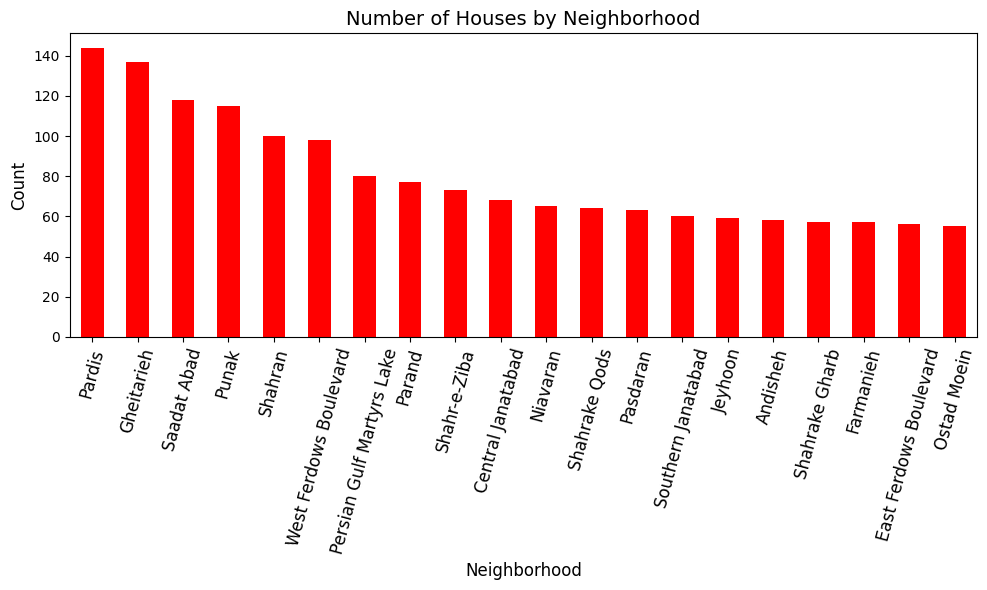

In [1714]:
counts = df['Address'].value_counts()
plt.figure(figsize=(10, 6))
counts[:20].plot(kind='bar' , color='red')
plt.title('Number of Houses by Neighborhood', fontsize=14)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=75,fontsize=12)
plt.tight_layout()
plt.show()

### 4.2 Encoding the non-numerical attributes in Linear regression :
-------------------------------------------------------------------------------------------------------------------------------------

###### Group by Address to calculate mean price per location
###### Group by Parking and Address to compute average price per parking availability at each address
###### Group by Warehouse and Address to find average price per warehouse status at each address
###### Group by Elevator and Address to determine average price per elevator presence at each address
###### Group by Room and Address to calculate average price per room category at each address
###### Convert each grouped result to a dictionary for easy lookup of (feature, address) pairs
###### These dictionaries enable quick comparison of how amenities affect prices within the same address

In [1703]:
mean_prices_address = df.groupby('Address')['Price'].mean()
mean_prices_Parking = df.groupby([
    "Parking",
    "Address"])['Price'].mean().to_dict()
mean_prices_Warehouse = df.groupby([
    "Warehouse",
    "Address"])['Price'].mean().to_dict()
mean_prices_Elevator = df.groupby([
    "Elevator",
    "Address"])['Price'].mean().to_dict()
mean_prices_Room = df.groupby([
    "Room",
    "Address"])['Price'].mean().to_dict()

In [1695]:
mean_prices_address
mean_prices_Parking
mean_prices_Room

{(0, 'Nasim Shahr'): 360000000.0,
 (0, 'Northern Chitgar'): 345000000.0,
 (0, 'Ostad Moein'): 575000000.0,
 (0, 'Pakdasht'): 165000000.0,
 (0, 'Parand'): 102000000.0,
 (0, 'Shahrake Qods'): 359000000.0,
 (1, 'Abbasabad'): 2460000000.0,
 (1, 'Abuzar'): 935000000.0,
 (1, 'Afsarieh'): 3150000000.0,
 (1, 'Ahang'): 1100000000.0,
 (1, 'Air force'): 1690000000.0,
 (1, 'Alborz Complex'): 645000000.0,
 (1, 'Amir Bahador'): 9800000000.0,
 (1, 'Andisheh'): 525891304.34782606,
 (1, 'Aqdasieh'): 3750000000.0,
 (1, 'Araj'): 3100000000.0,
 (1, 'Azarbaijan'): 1217777777.7777777,
 (1, 'Baghestan'): 510000000.0,
 (1, 'Beryanak'): 914333333.3333334,
 (1, 'Central Janatabad'): 2866923076.923077,
 (1, 'Chidz'): 3000000000.0,
 (1, 'Damavand'): 2621250000.0,
 (1, 'Dehkade Olampic'): 2000000000.0,
 (1, 'Dezashib'): 3150000000.0,
 (1, 'Dolatabad'): 695000000.0,
 (1, 'East Ferdows Boulevard'): 2005454545.4545455,
 (1, 'East Pars'): 1297500000.0,
 (1, 'Ekbatan'): 3115000000.0,
 (1, 'Ekhtiarieh'): 3533333333.3333

#### 4.3 Apply changes on data frame :
-------------------------------------------------------------------------------------------------------------------------------------


In [1696]:
df['Address_enc']=df['Address'].map(mean_prices_address)
df['Parking_enc']=df.apply(lambda row: mean_prices_Parking.get((row['Parking'], row['Address']), 0), axis=1)
df["Room_enc"] = df.apply(lambda row: mean_prices_Room.get((row['Room'], row['Address']), 0), axis=1)
df["Elevator_enc"] =df.apply(lambda row: mean_prices_Elevator.get((row['Elevator'], row['Address']), 0), axis=1)
df["Warehouse_enc"] = df.apply(lambda row: mean_prices_Warehouse.get((row['Warehouse'], row['Address']), 0), axis=1)

## 5 Preparing for train and test the model
-------------------------------------------------------------------------------------------------------------------------------------
###### train on %80 of tuples
###### test on %20 of tuples
-------------------------------------------------------------------------------------------------------------------------------------

In [1697]:
mask = np.random.rand(len(df)) < 0.8
train = df[mask]
test = df[~mask]

## 6 Data visualization

-------------------------------------------------------------------------------------------------------------------------------------

Create target-encoded features by mapping each categorical value to the mean price of its group: encode Address using the global mean price per address, encode Parking/Room/Elevator/Warehouse using the mean price for each combination of the feature and address (with a default of 0 if no matching group exists), effectively capturing how each amenity impacts price within the same location while avoiding one-hot encoding dimensionality explosion

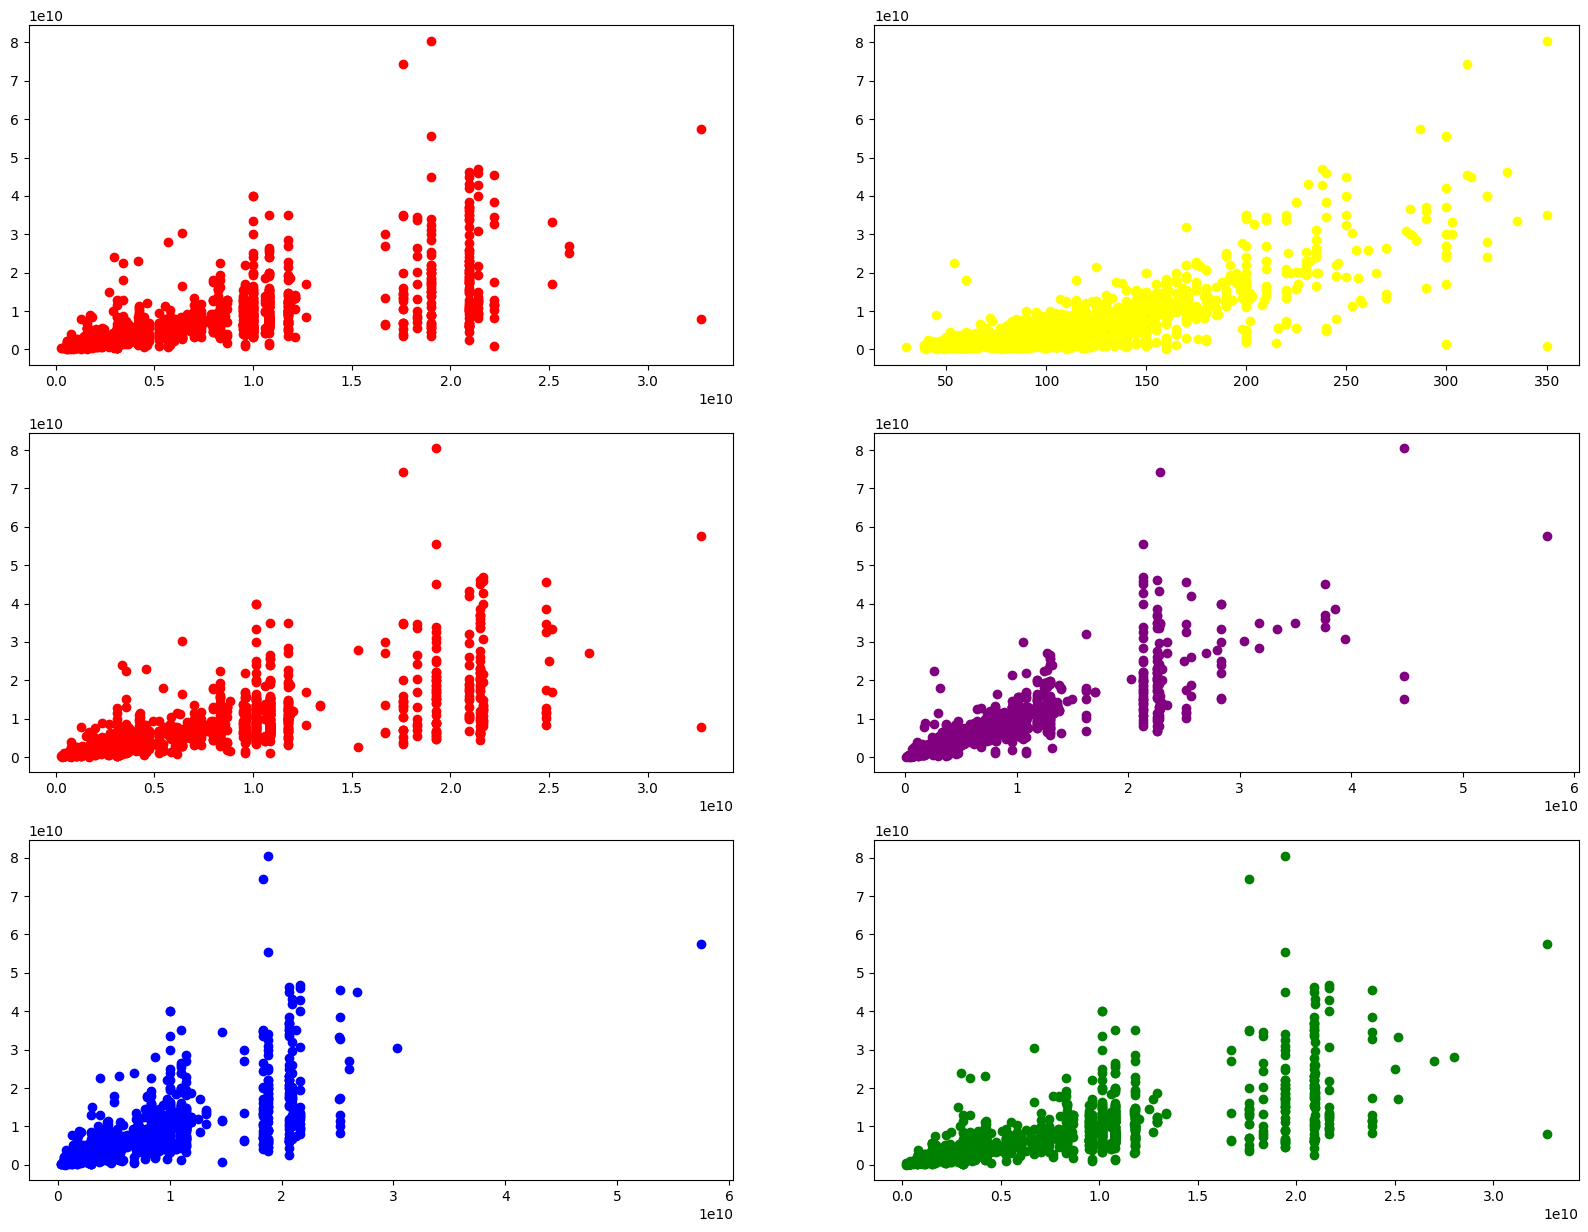

In [1698]:
fig , axes = plt.subplots(3,2,figsize = (20,15))
axes[0,0].scatter(train[['Address_enc']], train[['Price']],color='red')
axes[0,1].scatter(train[['Area']], train[['Price']],color='yellow')
axes[1,0].scatter(train[['Parking_enc']], train[['Price']],color='red')
axes[1,1].scatter(train[['Room_enc']], train[['Price']],color='purple')
axes[2,0].scatter(train[['Elevator_enc']], train[['Price']],color='blue')
axes[2,1].scatter(train[['Warehouse_enc']], train[['Price']],color='green')

## 7 fit the linear regression for the attributes
-------------------------------------------------------------------------------------------------------------------------------------


In [1699]:
reg =LinearRegression()
reg.fit(train[['Address_enc','Area','Room_enc','Parking_enc','Elevator_enc']], train[['Price']])
test_answer = reg.predict(test[['Address_enc','Area','Room_enc','Parking_enc','Elevator_enc']])

## 8 Calculate the R2 score
-------------------------------------------------------------------------------------------------------------------------------------

In [1707]:
_err = metrics.r2_score(test[['Price']], test_answer)
print("%.2f" % _err)

0.83



##### Tuning Results
##### Best R2 Score on test: 0.8674



Create target-encoded features by mapping each categorical value to the mean price of its group: encode Address using the global mean price per address, encode Parking/Room/Elevator/Warehouse using the mean price for each combination of the feature and address (with a default of 0 if no matching group exists), effectively capturing how each amenity impacts price within the same location; adding a 'YearBuilt' feature would improve these encodings by factoring in property age, as newer buildings typically command higher prices and can help disentangle the effect of construction year from neighborhood trends and amenity values